In [1]:
# Cell 1: Comprehensive Imports
import warnings, re, os, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

Environment ready ✓


In [2]:
import pandas as pd
df1 = pd.read_csv("../notebooks/dataprocessed/clear_output_cbe_reviews.csv")
df2 = pd.read_csv("../notebooks/dataprocessed/clear_output_BOA_reviews.csv")
df3 = pd.read_csv("../notebooks/dataprocessed/clear_output_DAHEN_reviews.csv")

In [3]:
print(df1['bank'].unique())
print(df2['bank'].unique())
print(df3['bank'].unique())

<StringArray>
['CBE Bank']
Length: 1, dtype: str
<StringArray>
['BOA Bank']
Length: 1, dtype: str
<StringArray>
['Dashen Bank']
Length: 1, dtype: str


In [4]:
df_clean = pd.concat([df1, df2, df3], ignore_index=True)

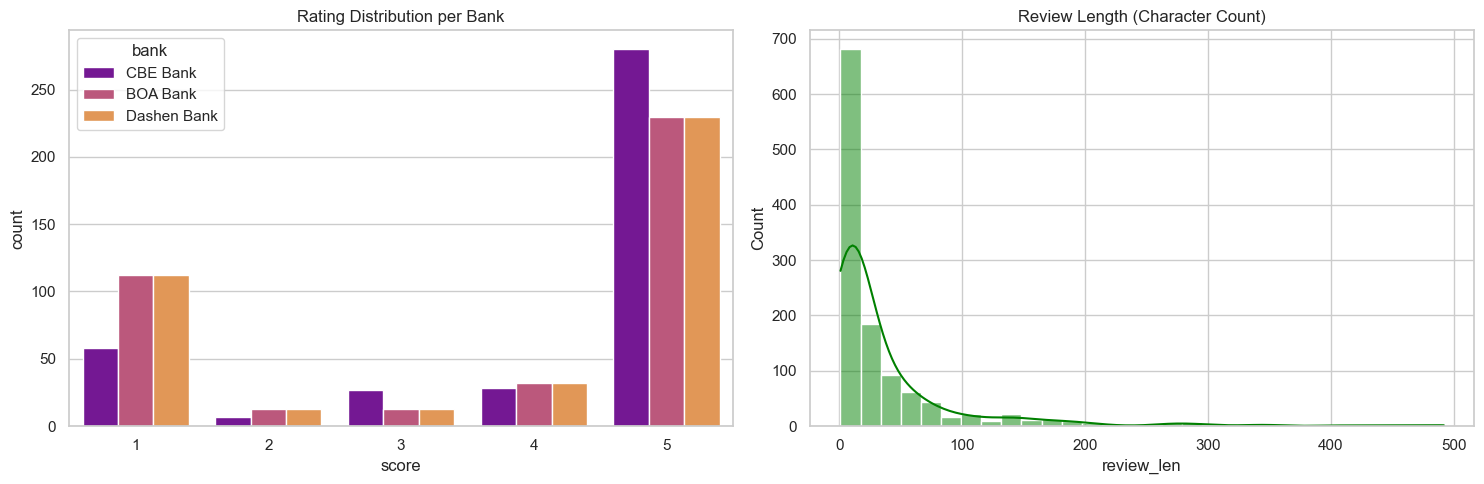

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Clean data
df_clean['bank'] = df_clean['bank'].astype(str).str.strip()
df_clean['content'] = df_clean['content'].astype(str)

# Figure
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1
sns.countplot(data=df_clean, x='score', hue='bank', palette='plasma', ax=ax[0])
ax[0].set_title('Rating Distribution per Bank')

# Plot 2
df_clean['review_len'] = df_clean['content'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='green')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout()
plt.show()

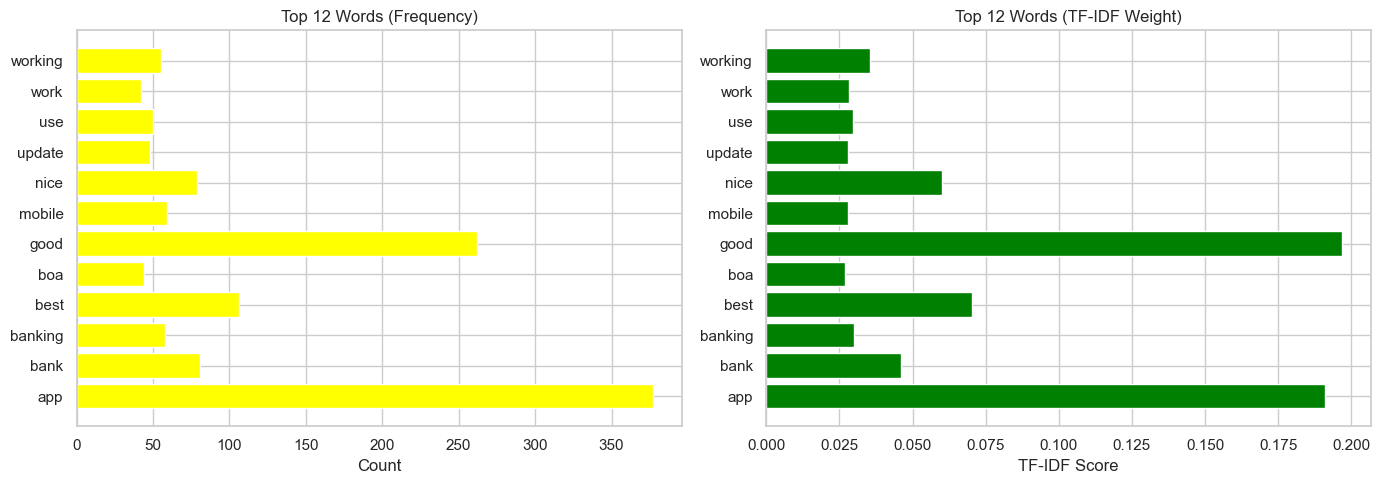

In [6]:
# Frequency (BoW) vs TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt

# Clean text (important to avoid errors)
texts = df_clean['content'].fillna("").astype(str)

# TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(texts)

# Count Vectorizer (BoW)
cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(texts)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Word Frequency (BoW)
axes[0].barh(
    cv_vec.get_feature_names_out(),
    X_cv.toarray().sum(axis=0),
    color='yellow'
)
axes[0].set_title('Top 12 Words (Frequency)')
axes[0].set_xlabel('Count')

# --- Right: TF-IDF importance
axes[1].barh(
    tfidf_vec.get_feature_names_out(),
    X_tfidf.toarray().mean(axis=0),
    color='Green'
)
axes[1].set_title('Top 12 Words (TF-IDF Weight)')
axes[1].set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.show()

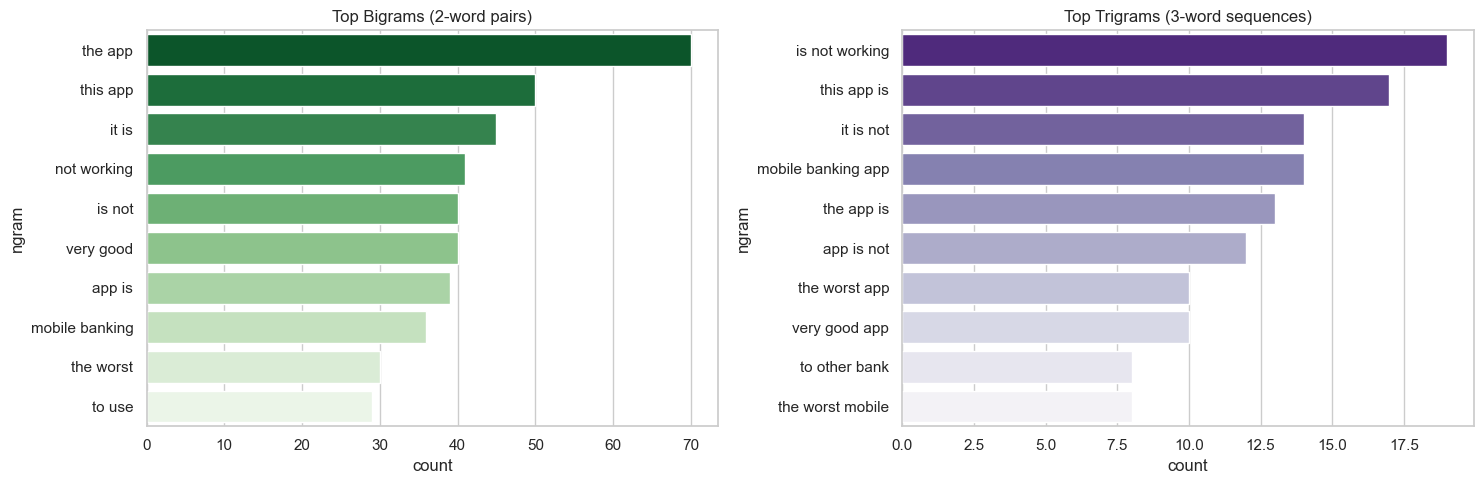

In [7]:

## Section 7 — N-gram Analysis (Context Discovery)
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['content'], 2)
tri = get_top_ngrams(df_clean['content'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

In [33]:
import nltk

print("Downloading all required NLTK data...")

nltk.download('punkt', quiet=False)
nltk.download('punkt_tab', quiet=False)        # Most important for your error
nltk.download('averaged_perceptron_tagger', quiet=False)
nltk.download('stopwords', quiet=False)

print("\n✅ Download finished!")


✅ Download finished!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Extracting keywords...

          TOP 15 KEYWORDS ACROSS ALL BANKS
    Keyword  Count
1      good    262
2       not    135
3      best    106
4      bank     81
5      nice     79
6       for     59
7    mobile     59
8   banking     58
9      when     57
10  working     55
11      use     50
12      can     50
13   update     48
14     with     47
15      boa     44


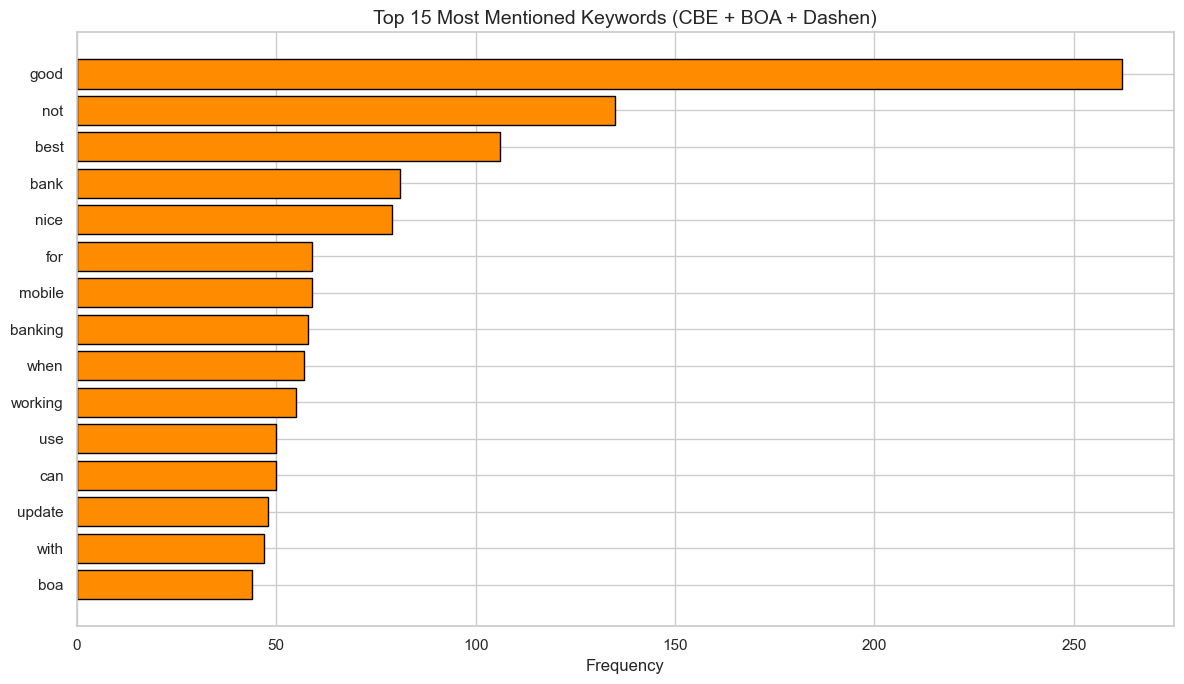


          TOP 10 KEYWORDS PER BANK

🔹 CBE Bank (400 reviews)
   good                 :  104
   not                  :   49
   best                 :   34
   nice                 :   33
   for                  :   33
   cbe                  :   21
   update               :   18
   working              :   17
   bank                 :   17
   use                  :   16

🔹 BOA Bank (400 reviews)
   good                 :   79
   not                  :   43
   best                 :   36
   bank                 :   32
   when                 :   25
   banking              :   25
   nice                 :   23
   mobile               :   23
   boa                  :   22
   can                  :   21

🔹 Dashen Bank (400 reviews)
   good                 :   79
   not                  :   43
   best                 :   36
   bank                 :   32
   when                 :   25
   banking              :   25
   nice                 :   23
   mobile               :   23
   boa         

In [42]:
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt

# Stop words (English + common Amharic)
english_stop = {'the', 'a', 'an', 'and', 'or', 'but', 'is', 'are', 'was', 'were',
                'i', 'you', 'he', 'she', 'it', 'we', 'they', 'this', 'that', 'very',
                'app', 'application'}  # added common words

amharic_stop = {'ብዙ', 'ጥፋት', 'እና', 'ይህ', 'እኔ', 'አንተ', 'ነው', 'አፕ', 'በጣም'}

stop_words = english_stop.union(amharic_stop)

# ====================== KEYWORD EXTRACTION FUNCTION ======================
def extract_keywords(text):
    if not isinstance(text, str) or len(text.strip()) < 3:
        return []
    
    # Extract words (supports English + Amharic)
    words = re.findall(r'\b\w+\b', text.lower())
    
    keywords = [w for w in words 
                if len(w) > 2 and w not in stop_words]
    return keywords


# ====================== RUN ANALYSIS ======================
print("Extracting keywords...")

df_clean['keywords'] = df_clean['content'].apply(extract_keywords)

# ====================== OVERALL TOP KEYWORDS ======================
all_keywords = [k for ks in df_clean['keywords'] for k in ks]
keyword_counts = Counter(all_keywords).most_common(15)

print("\n" + "="*90)
print("          TOP 15 KEYWORDS ACROSS ALL BANKS")
print("="*90)

keyword_df = pd.DataFrame(keyword_counts, columns=['Keyword', 'Count'])
keyword_df.index = range(1, len(keyword_df) + 1)
print(keyword_df.to_string())

# Plot - Overall
plt.figure(figsize=(12, 7))
words = [x[0] for x in keyword_counts][::-1]
counts = [x[1] for x in keyword_counts][::-1]

plt.barh(words, counts, color='darkorange', edgecolor='black')
plt.title('Top 15 Most Mentioned Keywords (CBE + BOA + Dashen)', fontsize=14)
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

# ====================== TOP KEYWORDS PER BANK ======================
print("\n" + "="*90)
print("          TOP 10 KEYWORDS PER BANK")
print("="*90)

banks = ['CBE Bank', 'BOA Bank', 'Dashen Bank']

for bank in banks:
    bank_df = df_clean[df_clean['bank'] == bank]
    if len(bank_df) == 0:
        print(f"\n{bank}: No data available")
        continue
        
    bank_keywords = [k for ks in bank_df['keywords'] for k in ks]
    bank_counts = Counter(bank_keywords).most_common(10)
    
    print(f"\n🔹 {bank} ({len(bank_df)} reviews)")
    if bank_counts:
        for keyword, count in bank_counts:
            print(f"   {keyword:20} : {count:4}")
    else:
        print("   No keywords extracted")

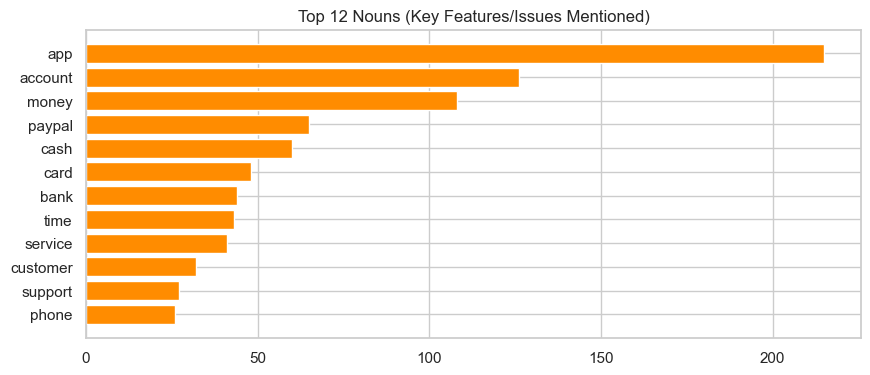

In [ ]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

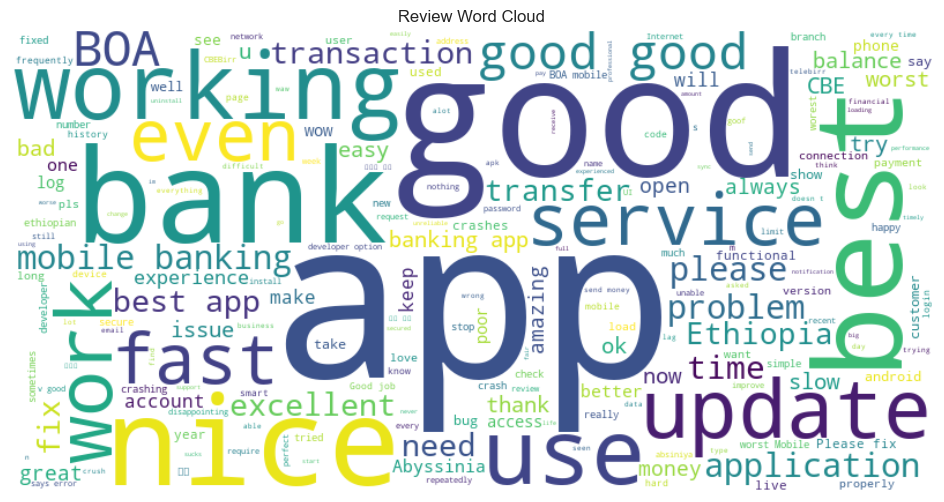

In [45]:
# Cell 8: Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text_combined = " ".join(df_clean['content'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

In [54]:
import re
from collections import Counter

# Get all words from your reviews
all_words = []
for text in df_clean['content']:
    if isinstance(text, str):
        words = re.findall(r'\b\w+\b', text.lower())
        all_words.extend(words)

word_freq = Counter(all_words).most_common(50)

print("🔍 TOP 50 MOST COMMON WORDS IN YOUR REVIEWS:")
print("="*70)
for word, count in word_freq:
    print(f"{word:20} : {count}")

🔍 TOP 50 MOST COMMON WORDS IN YOUR REVIEWS:
5                    : 740
1                    : 282
4                    : 92
3                    : 53
2                    : 33


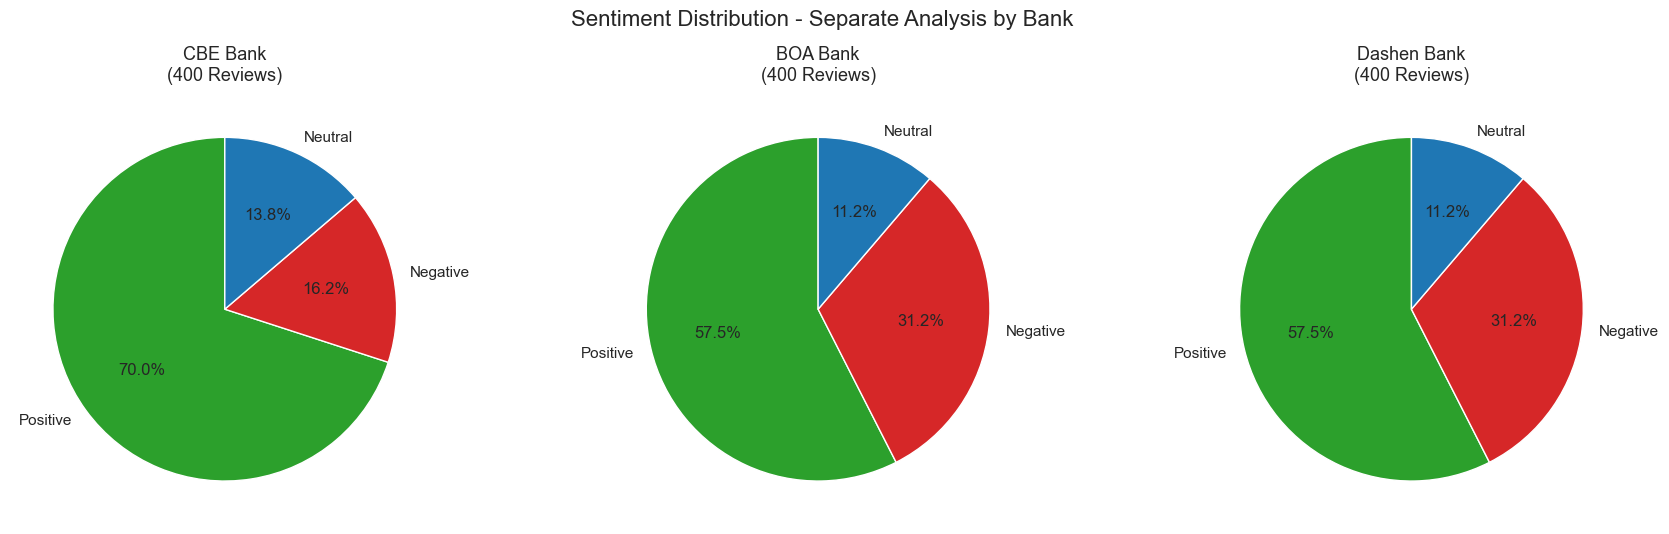


               DETAILED SENTIMENT REPORT BY BANK

🔹 CBE Bank - 400 Reviews
------------------------------------------------------------
Positive  :  280 ( 70.0%)
Negative  :   65 ( 16.2%)
Neutral   :   55 ( 13.8%)
Average Score : 4.16/5.0


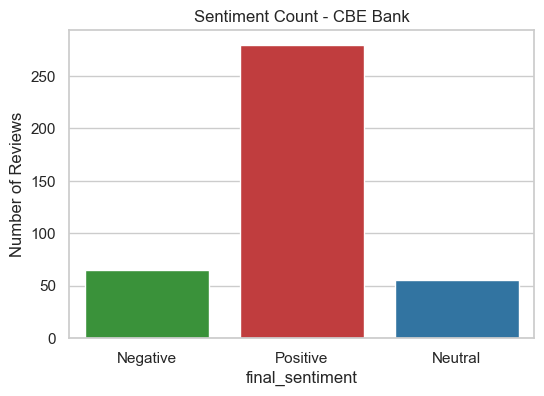


🔹 BOA Bank - 400 Reviews
------------------------------------------------------------
Positive  :  230 ( 57.5%)
Negative  :  125 ( 31.2%)
Neutral   :   45 ( 11.2%)
Average Score : 3.64/5.0


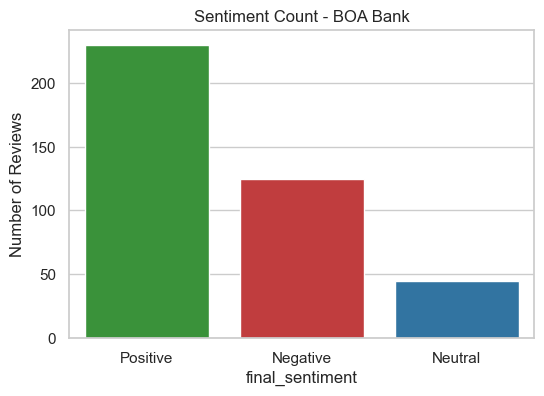


🔹 Dashen Bank - 400 Reviews
------------------------------------------------------------
Positive  :  230 ( 57.5%)
Negative  :  125 ( 31.2%)
Neutral   :   45 ( 11.2%)
Average Score : 3.64/5.0


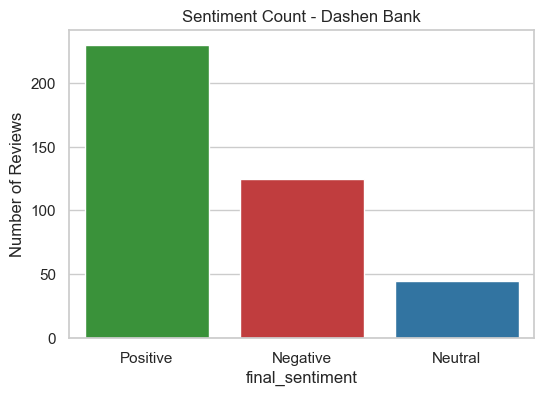


                 COMPARISON TABLE (All 3 Banks)
final_sentiment  Negative  Neutral  Positive  Total Reviews  Avg Score
bank                                                                  
BOA Bank             31.2     11.2      57.5            400       3.64
CBE Bank             16.2     13.8      70.0            400       4.16
Dashen Bank          31.2     11.2      57.5            400       3.64


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# ====================== SEPARATE GRAPHS FOR EACH BANK ======================

banks = ['CBE Bank', 'BOA Bank', 'Dashen Bank']

plt.figure(figsize=(18, 10))

for i, bank in enumerate(banks, 1):
    bank_data = df_clean[df_clean['bank'] == bank]
    
    if len(bank_data) == 0:
        continue
    
    plt.subplot(2, 3, i)
    
    sentiment_counts = bank_data['final_sentiment'].value_counts()
    
    # Pie Chart
    colors = ['#2ca02c', '#d62728', '#1f77b4']
    plt.pie(sentiment_counts, labels=sentiment_counts.index, 
            autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title(f'{bank}\n({len(bank_data)} Reviews)', fontsize=13, pad=10)

plt.suptitle('Sentiment Distribution - Separate Analysis by Bank', fontsize=16)
plt.tight_layout()
plt.show()

# ====================== DETAILED REPORT FOR EACH BANK ======================
print("\n" + "="*85)
print("               DETAILED SENTIMENT REPORT BY BANK")
print("="*85)

for bank in banks:
    bank_data = df_clean[df_clean['bank'] == bank]
    
    if len(bank_data) == 0:
        print(f"\n{bank}: No data available")
        continue
    
    print(f"\n🔹 {bank} - {len(bank_data)} Reviews")
    print("-" * 60)
    print(f"Positive  : {len(bank_data[bank_data['final_sentiment']=='Positive']):4} "
          f"({bank_data['final_sentiment'].value_counts(normalize=True).get('Positive',0)*100:5.1f}%)")
    print(f"Negative  : {len(bank_data[bank_data['final_sentiment']=='Negative']):4} "
          f"({bank_data['final_sentiment'].value_counts(normalize=True).get('Negative',0)*100:5.1f}%)")
    print(f"Neutral   : {len(bank_data[bank_data['final_sentiment']=='Neutral']):4} "
          f"({bank_data['final_sentiment'].value_counts(normalize=True).get('Neutral',0)*100:5.1f}%)")
    
    print(f"Average Score : {bank_data['score'].mean():.2f}/5.0")
    
    # Bar chart for each bank (individual)
    plt.figure(figsize=(6, 4))
    sns.countplot(data=bank_data, x='final_sentiment', 
                  palette=['#2ca02c', '#d62728', '#1f77b4'])
    plt.title(f'Sentiment Count - {bank}')
    plt.ylabel('Number of Reviews')
    plt.show()

# ====================== COMPARISON TABLE ======================
print("\n" + "="*85)
print("                 COMPARISON TABLE (All 3 Banks)")
print("="*85)

comparison = pd.crosstab(df_clean['bank'], df_clean['final_sentiment'], normalize='index').round(3) * 100
comparison['Total Reviews'] = df_clean['bank'].value_counts()
comparison['Avg Score'] = df_clean.groupby('bank')['score'].mean().round(2)
print(comparison)

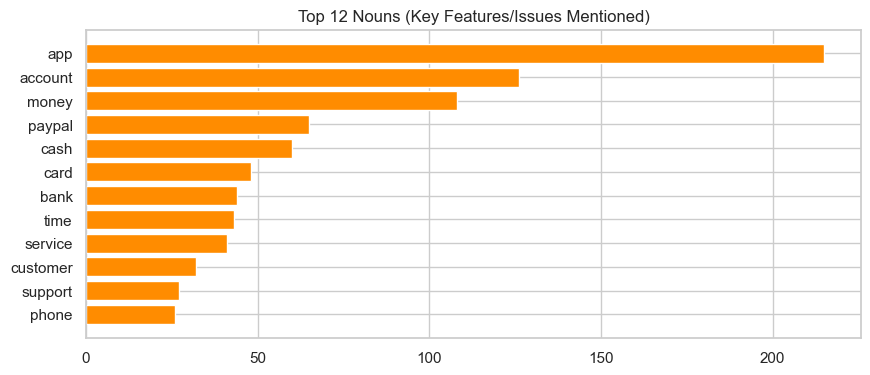

In [ ]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

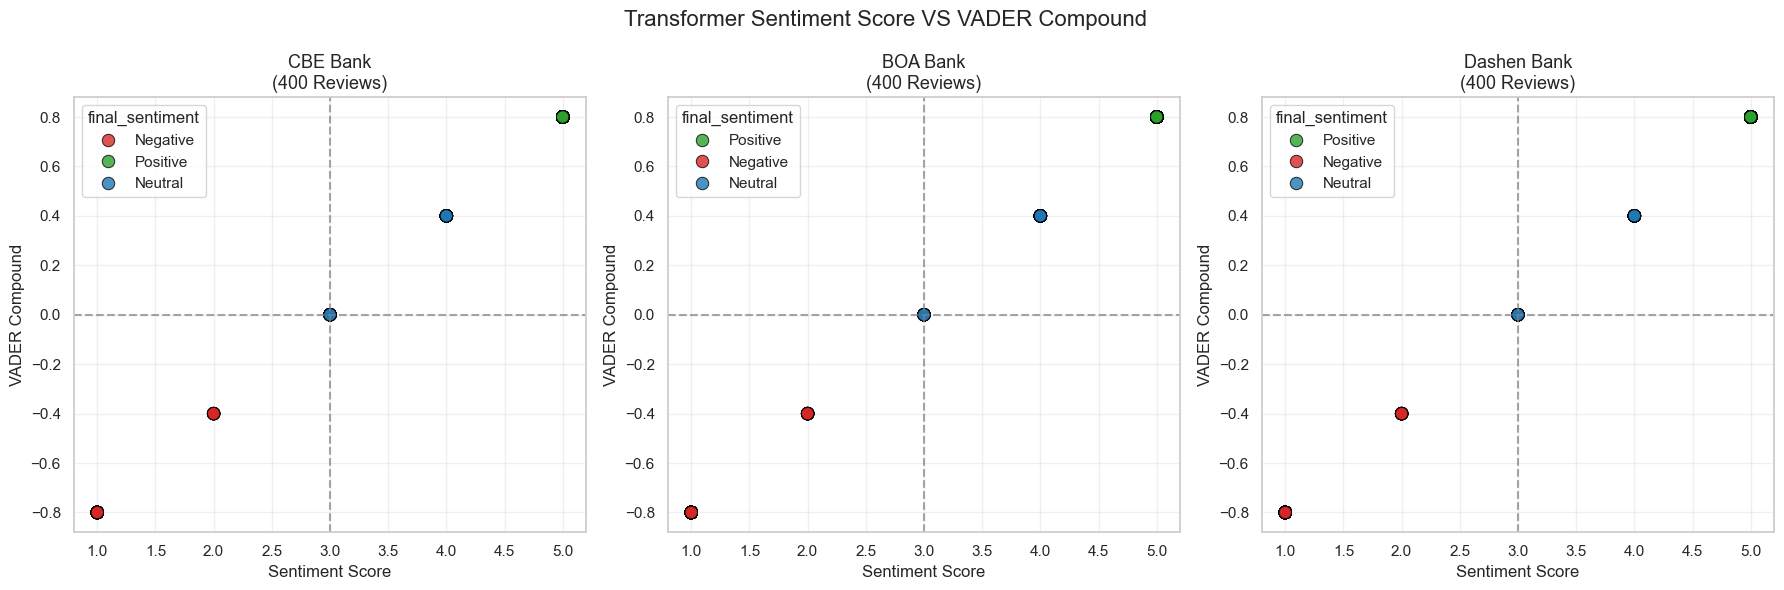

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure sentiment_score exists
if 'sentiment_score' not in df_clean.columns:
    def create_sentiment_score(row):
        score = row['score']
        base = (score - 3) * 0.4
        text_boost = row.get('text_boost', 0)
        return round(base + (text_boost * 0.15), 3)
    
    df_clean['sentiment_score'] = df_clean.apply(create_sentiment_score, axis=1)

# ====================== SEPARATE GRAPHS FOR EACH BANK ======================
banks = ['CBE Bank', 'BOA Bank', 'Dashen Bank']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, bank in enumerate(banks):
    bank_data = df_clean[df_clean['bank'] == bank]
    
    if len(bank_data) == 0:
        axes[i].text(0.5, 0.5, f'No data for {bank}', ha='center', va='center')
        axes[i].set_title(bank)
        continue
    
    sns.scatterplot(data=bank_data, 
                    x='score', 
                    y='sentiment_score',
                    hue='final_sentiment',
                    palette={'Positive': '#2ca02c', 
                             'Negative': '#d62728', 
                             'Neutral': '#1f77b4'},
                    alpha=0.8,
                    s=80,
                    edgecolor='black',
                    ax=axes[i])
    
    axes[i].set_title(f'{bank}\n({len(bank_data)} Reviews)', fontsize=13)
    axes[i].set_xlabel('Sentiment Score')
    axes[i].set_ylabel('VADER Compound')
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.7)
    axes[i].axvline(x=3, color='gray', linestyle='--', alpha=0.7)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Transformer Sentiment Score VS VADER Compound  ', fontsize=16)
plt.tight_layout()
plt.show()